# Objective to train a model to separate disease from cell type
Why are we interested in this? 
We want to know if there are features which cosine similarity does not caputre which a ML model can capture which separate disease from control. This would tell us that the embeddings DO have disease specific information in their embeddings.

## Load Data

In [1]:
"""Load Data
Structure:
    1. Imports, Variables, Functions
    2. Load Data
"""

# 1. Imports, Variables, Functions
# imports
import pandas as pd, numpy as np, os, sys
import anndata as ad
import logging
from typing import *
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.metrics import confusion_matrix, classification_report
import sys
sys.path.append(os.path.join("..", ".."))
from src.utils import utils as ut
from src.utils import viz as vz
from src.utils import io 
logging.basicConfig(level=logging.INFO)

# variables
# run_dir = os.path.join("..", "outputs", "run-25-05-01-01")  # doid - no controls
# run_dir = os.path.join("..", "outputs", "run-25-05-07-01")  # doid - grouped diseases
run_dir = os.path.join("..", "outputs", "run-25-07-08-07")  # doid - grouped diseases - ECS
# run_dir = os.path.join("..", "outputs", "run-25-07-09-05")  # doid - grouped diseases - DAB
# run_dir = os.path.join("..", "outputs", "run-25-05-07-02")  # doid - control + dataset
run_dir = os.path.join("..","outputs","run-25-07-24-02")
run_dir = os.path.join("..","outputs","run-25-07-26-01")
run_dir = os.path.join("..","outputs","run-25-08-04-08") # doid - grouped multilabel lvl1
run_dir = os.path.join("..","outputs","run-25-08-05-01") # doid - grouped multilabel bot 50
run_dir = os.path.join("..","..","outputs","run-25-08-08-02") # doid - grouped multilabel CLS
run_dir = os.path.join("..","..","outputs","run-25-08-08-03") # doid - grouped multilabel CLS_MULTILABEL
run_dir = os.path.join("..","..","outputs","run-25-08-18-03") # doid - RNA-seq multilabel top 50 CLS_MULTILABEL
run_dir = os.path.join("..","..","outputs","run-25-08-19-01") # doid - RNA-seq multilabel lvl1 CLS_MULTILABEL
run_dir = os.path.join("..","..","outputs","run-25-08-20-01") # doid - RNA-seq multilabel lvl1 CLS_MULTILABEL + CONTROL
run_dir = os.path.join("..","..","outputs","run-25-08-21-01") # doid - RNA-seq multilabel lvl1 CLS_MULTILABEL + CONTROL + NEW LOSS
run_dir = os.path.join("..","..","outputs","run-25-08-21-02") # doid - RNA-seq multilabel top 50 CLS_MULTILABEL + CONTROL + NEW LOSS
# run_dir = os.path.join("..","..","outputs","run-25-08-21-03") # doid - RNA-seq multilabel lvl1 CLS_MULTILABEL + CONTROL + NEW LOSS x 5 times effect
# run_dir = os.path.join("..","..","outputs","run-25-08-22-06") # doid - RNA-seq multilabel lvl1 CLS_MULTILABEL + CONTROL + NEW LOSS + COMBAT
run_dir = os.path.join("..","..","outputs","run-25-08-23-02") # doid - RNA-seq multilabel lvl50 CLS_MULTILABEL + CONTROL + 0.2 NEW LOSS + COMBAT
# run_dir = os.path.join("..","..","outputs","run-25-08-27-08") # doid - RNA-seq multilabel lvl50 CLS_MULTILABEL + CONTROL + 0.2 NEW LOSS + COMBAT
# run_dir = os.path.join("..","..","outputs","run-25-08-28-02") # doid - RNA-seq multilabel lvl50 CLS_MULTILABEL + CONTROL + 0.2 NEW LOSS + COMBAT + TOP LOG2FC
# run_dir = os.path.join("..","..","outputs","run-25-08-31-01") # doid - RNA-seq multilabel lvl50 CLS_MULTILABEL + CONTROL + 0.2 NEW LOSS + COMBAT + TOP LOG2FC + 7k
run_dir = os.path.join("..","..","outputs","run-25-09-03-01") # A 
output_dir = os.path.join(run_dir, "outputs")


if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# functions

# 2. Load Data
(
    # split,
    predictions_test,
    labels_test,
    results_test,
    all_outputs_test,
    predictions_valid,
    labels_valid,
    results_valid,
    all_outputs_valid,
    predictions_train,
    labels_train,
    results_train,
    all_outputs_train,
    adata_orig,
    id2type,
    train_indices,
    valid_indices,
) = io.load_run_output(run_dir)

# load json

with open(os.path.join(run_dir, "parameters.json"), "r") as f:
    parameters = json.load(f)

for k, v in parameters.items():
    print(f"{k}: {v}")

Nº of loaded variables 16
data_path: /aloy/home/ddalton/projects/scGPT_playground/data/pp_data-25-08-14-01/data.h5ad
max_seq_len: 3501
batch_size: 16
gene_presence_pct: 0.9
benchmark_data: False
split_type: stratified
val_split_type: random
n_splits: 10
n_tested_splits: 10
epochs: 50
gene_filtering: top_presence
sample_presence_pct: 0.3
MLM: False
CLS: False
CLS_multilabel: True
DAB: False
ADV: False
CCE: False
ecs_thres: 0.0
dab_weight: 0.0
use_fast_transformer: True
output_attentions: False
INPUT_BATCH_LABELS: False
do_combat: False
ontology: do
scgpt_pp: norm_log1p
description: log1CPM, Counts norm. ; 3.5k genes Presence + Variance ; 50 Disease Families


In [2]:
# 2. Load Data
split_idx = 0 

# load all adata
adata_test =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_test_{split_idx+1}.h5ad"), backed="r"
)
adata_test.obs.reset_index(drop=True, inplace=True)  
adata_valid =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_valid_{split_idx+1}.h5ad"), backed="r"
)
adata_valid.obs.reset_index(drop=True, inplace=True)  
adata_train =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_train_{split_idx+1}.h5ad"), backed="r"
)
adata_train.obs.reset_index(drop=True, inplace=True)  

# get embeddings!
embeddings_test = vz.merge_embeddings(all_outputs_test[split_idx])
embeddings_valid = vz.merge_embeddings(all_outputs_valid[split_idx])
embeddings_train = vz.merge_embeddings(all_outputs_train[split_idx])

## Model Predict Control vs Disease Condition

### scGPT Embeddings

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import *
from torch import Tensor
from torch.utils.data import DataLoader, TensorDataset

class CONDdecoder(nn.Module):
    def __init__(self, d_input, d_hidden, d_output, dropout, activation)->None:
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(d_input, d_hidden),
            activation,
            nn.Dropout(dropout),
            nn.Linear(d_hidden, d_hidden),
            activation,
            nn.Dropout(dropout),
            nn.Linear(d_hidden, d_output),
        )

    def forward(self, x: Tensor) -> Tensor:
        logits = self.layers(x)
        return logits

def train_loop(dataloader, model, loss_fn, optimizer, batch_size):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred.squeeze(1), y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        if batch % 100 == 0:
            current = batch*batch_size+len(X)
            print(f"loss: {loss.item():>7f}  [{current:>5d}/{size:>5d}]")


def test_loop(dataloader, model, loss_fn, batch_size):
    size = len(dataloader.dataset)
    model.eval()
    all_preds = []
    test_loss = 0
    correct = 0
    with torch.no_grad():   # no gradient calculation
        for batch, (X, y) in enumerate(dataloader):
            pred = model(X)
            loss = loss_fn(pred.squeeze(1),y)
            all_preds.append(pred)
            test_loss += loss.item()
            probs = torch.sigmoid(pred)
            preds = (probs >= 0.5).long()
            correct += (preds == y.long()).sum().item()
            
    test_loss /= size
    accuracy = correct / size
    print(f"Test Error: \n Accuracy: {(100*accuracy):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    return all_preds



/tmp/ipykernel_10210/2860452999.py:74: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype=torch.float32)
/tmp/ipykernel_10210/2860452999.py:75: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_valid = torch.tensor(y_valid, dtype=torch.float32)
/tmp/ipykernel_10210/2860452999.py:76: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_test = torch.tensor(y_test, dtype=torch.float32)


Epoch 1
-------------------------------
loss: 0.702285  [   32/23184]
loss: 0.676429  [ 3232/23184]
loss: 0.681067  [ 6432/23184]
loss: 0.670322  [ 9632/23184]
loss: 0.653587  [12832/23184]
loss: 0.620677  [16032/23184]
loss: 0.646458  [19232/23184]
loss: 0.642830  [22432/23184]
Test Error: 
 Accuracy: 1849.6%, Avg loss: 0.019576 

Epoch 2
-------------------------------
loss: 0.602206  [   32/23184]
loss: 0.630386  [ 3232/23184]
loss: 0.690826  [ 6432/23184]
loss: 0.553564  [ 9632/23184]
loss: 0.532966  [12832/23184]
loss: 0.516691  [16032/23184]
loss: 0.624814  [19232/23184]
loss: 0.545100  [22432/23184]
Test Error: 
 Accuracy: 1700.6%, Avg loss: 0.017207 

Epoch 3
-------------------------------
loss: 0.505325  [   32/23184]
loss: 0.555538  [ 3232/23184]
loss: 0.516624  [ 6432/23184]
loss: 0.445459  [ 9632/23184]
loss: 0.397418  [12832/23184]
loss: 0.420324  [16032/23184]
loss: 0.556799  [19232/23184]
loss: 0.426846  [22432/23184]
Test Error: 
 Accuracy: 1647.5%, Avg loss: 0.015589 

/tmp/ipykernel_10210/1059318167.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype=torch.float32)
/tmp/ipykernel_10210/1059318167.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_valid = torch.tensor(y_valid, dtype=torch.float32)
/tmp/ipykernel_10210/1059318167.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_test = torch.tensor(y_test, dtype=torch.float32)


Epoch 1
-------------------------------
loss: 0.699131  [   32/23184]
loss: 0.450345  [ 3232/23184]
loss: 0.397325  [ 6432/23184]
loss: 0.303325  [ 9632/23184]
loss: 0.318951  [12832/23184]
loss: 0.211938  [16032/23184]
loss: 0.368531  [19232/23184]
loss: 0.350875  [22432/23184]
Test Error: 
 Accuracy: 1683.6%, Avg loss: 0.014185 

Epoch 2
-------------------------------
loss: 0.317375  [   32/23184]
loss: 0.391766  [ 3232/23184]
loss: 0.372815  [ 6432/23184]
loss: 0.431780  [ 9632/23184]
loss: 0.291523  [12832/23184]
loss: 0.323070  [16032/23184]
loss: 0.362971  [19232/23184]
loss: 0.374174  [22432/23184]
Test Error: 
 Accuracy: 1688.7%, Avg loss: 0.013798 

Epoch 3
-------------------------------
loss: 0.400378  [   32/23184]
loss: 0.267936  [ 3232/23184]
loss: 0.218645  [ 6432/23184]
loss: 0.301111  [ 9632/23184]
loss: 0.435436  [12832/23184]
loss: 0.383466  [16032/23184]
loss: 0.233666  [19232/23184]
loss: 0.314166  [22432/23184]
Test Error: 
 Accuracy: 1686.2%, Avg loss: 0.013948 

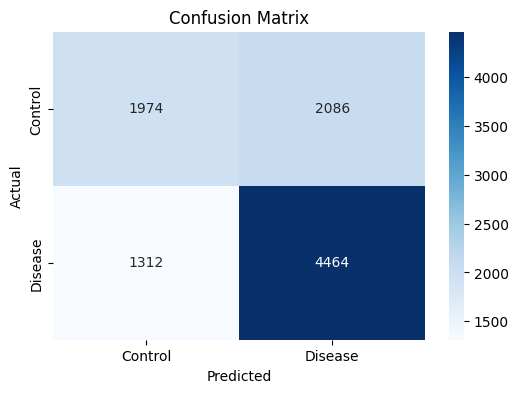

In [ ]:
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score  
import matplotlib.pyplot as plt
import seaborn as sns


# load data
# get binary labels 0 = control, 1 = disease
y_test = np.array((adata_test.obs["disease"]!="Control").astype(int))
y_valid = np.array((adata_valid.obs["disease"]!="Control").astype(int))
y_train = np.array((adata_train.obs["disease"]!="Control").astype(int))


# define model    
model = CONDdecoder(d_input=512, d_hidden=256, d_output=1, dropout=0.5, activation=nn.ReLU())

# prepare data
# convert arrays to tensors
X_train = torch.tensor(embeddings_train, dtype=torch.float32)
X_valid = torch.tensor(embeddings_valid, dtype=torch.float32)
X_test = torch.tensor(embeddings_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_valid = torch.tensor(y_valid, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)



training_data = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
validation_data = DataLoader(TensorDataset(X_valid, y_valid), batch_size=32, shuffle=False)
test_data = DataLoader(TensorDataset(X_test, y_test), batch_size=32, shuffle=False)

# define loss function & optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)

# train model
epochs = 20
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(training_data, model, loss_fn, optimizer, batch_size=32)
    test_loop(validation_data, model, loss_fn, batch_size=32)
print("Done!")
pred_test = test_loop(test_data, model, loss_fn, batch_size=32)





# apply sigmoid
pred_test = torch.sigmoid(torch.vstack(pred_test)).numpy()

roc_auc = roc_auc_score(y_test, pred_test)
print(f"ROC AUC: {roc_auc:.4f}")

precision, recall, _ = precision_recall_curve(y_test, pred_test)
average_precision = average_precision_score(y_test, pred_test)
print(f"Average Precision: {average_precision:.4f}")

# compute F1 score
y_pred = (pred_test >= 0.5).astype(int)
f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1:.4f}")

# compute precision and recall
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# generate confusion matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")

# plot confusion matrix

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Control", "Disease"], yticklabels=["Control", "Disease"])
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix")
plt.show()

### GEx

Epoch 1
-------------------------------
loss: 22.182173  [   32/23184]
loss: 1.600327  [ 3232/23184]
loss: 0.874362  [ 6432/23184]
loss: 0.670582  [ 9632/23184]
loss: 0.825214  [12832/23184]
loss: 0.767316  [16032/23184]
loss: 0.657321  [19232/23184]
loss: 0.802341  [22432/23184]
Test Error: 
 Accuracy: 1896.2%, Avg loss: 0.029051 

Epoch 2
-------------------------------
loss: 0.764003  [   32/23184]
loss: 0.624341  [ 3232/23184]
loss: 0.695849  [ 6432/23184]
loss: 0.753691  [ 9632/23184]
loss: 0.601456  [12832/23184]
loss: 0.612584  [16032/23184]
loss: 0.607345  [19232/23184]
loss: 0.604095  [22432/23184]
Test Error: 
 Accuracy: 1909.4%, Avg loss: 0.020820 

Epoch 3
-------------------------------
loss: 0.608366  [   32/23184]
loss: 0.678576  [ 3232/23184]
loss: 0.581650  [ 6432/23184]
loss: 0.634571  [ 9632/23184]
loss: 0.605446  [12832/23184]
loss: 0.571675  [16032/23184]
loss: 0.668028  [19232/23184]
loss: 0.651694  [22432/23184]
Test Error: 
 Accuracy: 1909.3%, Avg loss: 0.021136

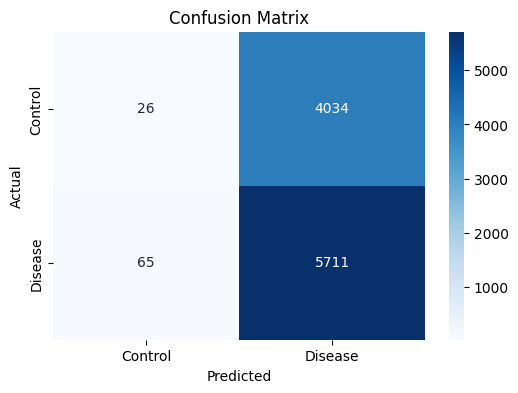

In [113]:
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score  
import matplotlib.pyplot as plt
import seaborn as sns

# load data
# get binary labels 0 = control, 1 = disease
y_test = np.array((adata_test.obs["disease"]!="Control").astype(int))
y_valid = np.array((adata_valid.obs["disease"]!="Control").astype(int))
y_train = np.array((adata_train.obs["disease"]!="Control").astype(int))

# GEx
X_train = np.array(adata_train.X)
X_valid = np.array(adata_valid.X)
X_test = np.array(adata_test.X)


# define model    
model = CONDdecoder(d_input=1000, d_hidden=256, d_output=1, dropout=0.5, activation=nn.ReLU())

# prepare data
# deal with nans in expression
X_train = np.nan_to_num(X_train, nan=0.0)
X_valid = np.nan_to_num(X_valid, nan=0.0)
X_test = np.nan_to_num(X_test, nan=0.0)

# convert arrays to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_valid = torch.tensor(X_valid, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)


y_train = torch.tensor(y_train, dtype=torch.float32)
y_valid = torch.tensor(y_valid, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)



training_data = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
validation_data = DataLoader(TensorDataset(X_valid, y_valid), batch_size=32, shuffle=False)
test_data = DataLoader(TensorDataset(X_test, y_test), batch_size=32, shuffle=False)

# define loss function & optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)

# train model
epochs = 20
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(training_data, model, loss_fn, optimizer, batch_size=32)
    test_loop(validation_data, model, loss_fn, batch_size=32)
print("Done!")
pred_test = test_loop(test_data, model, loss_fn, batch_size=32)

# apply sigmoid
pred_test = torch.sigmoid(torch.vstack(pred_test)).numpy()

roc_auc = roc_auc_score(y_test, pred_test)
print(f"ROC AUC: {roc_auc:.4f}")

precision, recall, _ = precision_recall_curve(y_test, pred_test)
average_precision = average_precision_score(y_test, pred_test)
print(f"Average Precision: {average_precision:.4f}")

# compute F1 score
y_pred = (pred_test >= 0.5).astype(int)
f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1:.4f}")

# compute precision and recall
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# generate confusion matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")

# plot confusion matrix

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Control", "Disease"], yticklabels=["Control", "Disease"])
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix")
plt.show()

## Predict diseases

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import *
from torch import Tensor
from torch.utils.data import DataLoader, TensorDataset

class DISdecoder(nn.Module):
    def __init__(self, d_input, d_hidden, d_output, dropout, activation)->None:
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(d_input, d_hidden),
            activation,
            nn.Dropout(dropout),
            nn.Linear(d_hidden, d_hidden),
            activation,
            nn.Dropout(dropout),
            nn.Linear(d_hidden, d_output),
        )

    def forward(self, x: Tensor) -> Tensor:
        logits = self.layers(x)
        return logits

def train_loop(dataloader, model, loss_fn, optimizer, batch_size):
    model.train()
    total, correct, total_loss = 0, 0, 0.0

    for X, y in dataloader:
        # y must be LongTensor with class ids
        y = y.long()

        optimizer.zero_grad(set_to_none=True)
        logits = model(X)                 # [B, C]
        loss = loss_fn(logits, y)         # CrossEntropyLoss

        loss.backward()
        optimizer.step()

        # metrics
        bs = X.size(0)
        total_loss += loss.item() * bs
        preds = logits.argmax(dim=1)      # [B]
        correct += (preds == y).sum().item()
        total += bs

    avg_loss = total_loss / total
    acc = correct / total
    print(f"Train: loss={avg_loss:.4f} acc={acc:.3f}")


def test_loop(dataloader, model, loss_fn, batch_size, name="Eval"):
    model.eval()
    total, correct, total_loss = 0, 0, 0.0
    all_logits = []

    with torch.no_grad():
        for X, y in dataloader:
            y = y.long()

            logits = model(X)             
            loss = loss_fn(logits, y)

            bs = X.size(0)
            total_loss += loss.item() * bs
            preds = logits.argmax(dim=1)     
            correct += (preds == y).sum().item()
            total += bs

            all_logits.append(logits.cpu())

    avg_loss = total_loss / total
    acc = correct / total
    print(f"{name}: loss={avg_loss:.4f} acc={acc:.3f}")
    return avg_loss


def predict(dataloader, model, loss_fn, batch_size, name="Eval"):
    model.eval()
    total, correct, total_loss = 0, 0, 0.0
    all_logits = []

    with torch.no_grad():
        for X, y in dataloader:
            y = y.long()

            logits = model(X)             
            loss = loss_fn(logits, y)

            bs = X.size(0)
            total_loss += loss.item() * bs
            preds = logits.argmax(dim=1)     
            correct += (preds == y).sum().item()
            total += bs

            all_logits.append(logits.cpu())

    avg_loss = total_loss / total
    acc = correct / total
    print(f"{name}: loss={avg_loss:.4f} acc={acc:.3f}")
    return torch.cat(all_logits, dim=0)   



In [13]:
# prepare data
# mask out controls
mask_train = adata_train.obs["doid_id"] != "Control"
mask_valid = adata_valid.obs["doid_id"] != "Control"
mask_test = adata_test.obs["doid_id"] != "Control"

# convert arrays to tensors
X_train = torch.tensor(embeddings_train[mask_train], dtype=torch.float32)
X_valid = torch.tensor(embeddings_valid[mask_valid], dtype=torch.float32)
X_test = torch.tensor(embeddings_test[mask_test], dtype=torch.float32)

y_train = torch.tensor(y_train[mask_train], dtype=torch.float32)
y_valid = torch.tensor(y_valid[mask_valid], dtype=torch.float32)
y_test = torch.tensor(y_test[mask_test], dtype=torch.float32)

training_data = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
validation_data = DataLoader(TensorDataset(X_valid, y_valid), batch_size=32, shuffle=False)
test_data = DataLoader(TensorDataset(X_test, y_test), batch_size=32, shuffle=False)

# define loss function & optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
loss_fn = nn.CrossEntropyLoss()
# train model
epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(training_data, model, loss_fn, optimizer, batch_size=64)
    test_loop(validation_data, model, loss_fn, batch_size=64)
print("Done!")


Epoch 1
-------------------------------
Train: loss=0.9960 acc=0.744
Eval: loss=0.5595 acc=0.834
Epoch 2
-------------------------------
Train: loss=0.4470 acc=0.860
Eval: loss=0.4819 acc=0.863
Epoch 3
-------------------------------
Train: loss=0.3378 acc=0.889
Eval: loss=0.4422 acc=0.875
Epoch 4
-------------------------------
Train: loss=0.2867 acc=0.905
Eval: loss=0.4410 acc=0.875
Epoch 5
-------------------------------
Train: loss=0.2482 acc=0.916
Eval: loss=0.4280 acc=0.891
Epoch 6
-------------------------------
Train: loss=0.2172 acc=0.925
Eval: loss=0.4507 acc=0.883
Epoch 7
-------------------------------
Train: loss=0.2015 acc=0.933
Eval: loss=0.4365 acc=0.886
Epoch 8
-------------------------------
Train: loss=0.1873 acc=0.937
Eval: loss=0.4429 acc=0.887
Epoch 9
-------------------------------
Train: loss=0.1686 acc=0.942
Eval: loss=0.4718 acc=0.892
Epoch 10
-------------------------------
Train: loss=0.1717 acc=0.941
Eval: loss=0.4665 acc=0.890
Done!


In [20]:
# convert doid to indices
dis_2_idx = {d: i for i, d in enumerate(adata_train.obs["doid_id"].unique())}
idx_2_dis = {i: d for d, i in dis_2_idx.items()}

y_test = np.array([dis_2_idx[d] for d in adata_test.obs["doid_id"]])
y_valid = np.array([dis_2_idx[d] for d in adata_valid.obs["doid_id"]])
y_train = np.array([dis_2_idx[d] for d in adata_train.obs["doid_id"]])

# define model    
model = DISdecoder(d_input=512, d_hidden=512, d_output=len(dis_2_idx), dropout=0.2, activation=nn.ReLU())


# prepare data
# convert arrays to tensors
X_train = torch.tensor(embeddings_train, dtype=torch.float32)
X_valid = torch.tensor(embeddings_valid, dtype=torch.float32)
X_test = torch.tensor(embeddings_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_valid = torch.tensor(y_valid, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

training_data = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
validation_data = DataLoader(TensorDataset(X_valid, y_valid), batch_size=32, shuffle=False)
test_data = DataLoader(TensorDataset(X_test, y_test), batch_size=32, shuffle=False)

# define loss function & optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2, verbose=True
)
loss_fn = nn.CrossEntropyLoss()
# train model
epochs = 50
patience = 10
best_val_loss = float("inf")
patience_counter = 0

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(training_data, model, loss_fn, optimizer, batch_size=64)
    val_loss = test_loop(validation_data, model, loss_fn, batch_size=64)

    scheduler.step(val_loss)
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model = model.state_dict()  # Save the best model state
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping triggered")
        break

model.load_state_dict(best_model)
print("Done!")


/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Epoch 1
-------------------------------
Train: loss=1.0725 acc=0.672
Eval: loss=0.9000 acc=0.673
Epoch 2
-------------------------------
Train: loss=0.7000 acc=0.732
Eval: loss=0.8295 acc=0.686
Epoch 3
-------------------------------
Train: loss=0.6261 acc=0.753
Eval: loss=0.8029 acc=0.697
Epoch 4
-------------------------------
Train: loss=0.5851 acc=0.759
Eval: loss=0.8149 acc=0.708
Epoch 5
-------------------------------
Train: loss=0.5460 acc=0.774
Eval: loss=0.7839 acc=0.716
Epoch 6
-------------------------------
Train: loss=0.5252 acc=0.778
Eval: loss=0.7827 acc=0.713
Epoch 7
-------------------------------
Train: loss=0.5064 acc=0.784
Eval: loss=0.7904 acc=0.710
Epoch 8
-------------------------------
Train: loss=0.4895 acc=0.791
Eval: loss=0.8201 acc=0.716
Epoch 9
-------------------------------
Train: loss=0.4716 acc=0.797
Eval: loss=0.8025 acc=0.703
Epoch 10
-------------------------------
Train: loss=0.3930 acc=0.823
Eval: loss=0.7906 acc=0.729
Epoch 11
--------------------

Eval: loss=10.3023 acc=0.273
ROC AUC (macro, OvR): 0.7618
Average Precision (macro): 0.1277
F1 (macro): 0.0783
Precision (macro): 0.0897
Recall (macro): 0.1289
Confusion Matrix (rows=actual, cols=predicted):


/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


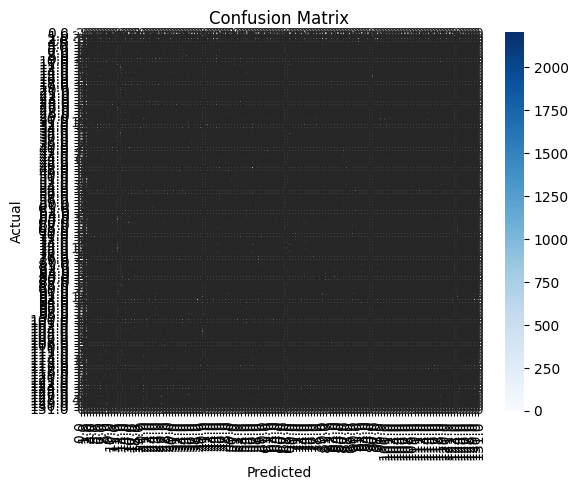

In [137]:
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    f1_score, precision_score, recall_score, confusion_matrix
)

# 1) Get logits from your test loop
logits_test = test_loop(test_data, model, loss_fn, batch_size=32)   # [N, C] torch tensor

# 2) Convert to probabilities and numpy
probs = torch.softmax(logits_test, dim=1).detach().cpu().numpy()    # [N, C]
y_true = y_test.detach().cpu().numpy() if torch.is_tensor(y_test) else y_test  # [N] ints 0..C-1

# Classes present (ensure consistent order)
classes = np.unique(y_true)
C = len(classes)

# 3) ROC AUC (multiclass, one-vs-rest)
y_true_bin = label_binarize(y_true, classes=classes)                # [N, C]
roc_auc = roc_auc_score(y_true_bin, probs, average="macro", multi_class="ovr")
print(f"ROC AUC (macro, OvR): {roc_auc:.4f}")

# 4) Average Precision (macro over classes)
avg_prec = average_precision_score(y_true_bin, probs, average="macro")
print(f"Average Precision (macro): {avg_prec:.4f}")

# (Optional) Per-class PR curves
# pr_curves = [precision_recall_curve(y_true_bin[:, k], probs[:, k]) for k in range(C)]

# 5) Discrete predictions for F1/precision/recall/confusion matrix
y_pred = probs.argmax(axis=1)                                       # [N]

f1 = f1_score(y_true, y_pred, average="macro")
prec = precision_score(y_true, y_pred, average="macro")
rec = recall_score(y_true, y_pred, average="macro")
print(f"F1 (macro): {f1:.4f}")
print(f"Precision (macro): {prec:.4f}")
print(f"Recall (macro): {rec:.4f}")

# 6) Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=classes)
print("Confusion Matrix (rows=actual, cols=predicted):")

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


In [147]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score

y_pred = probs.argmax(axis=1)  # predicted class labels
y_pred = (probs >= 0.5).astype(int)  # for multilabel

# 1) compute per-class F1
f1_per_class = f1_score(y_true, y_pred, average=None, labels=classes)

# 2) build a bar plot
plt.figure(figsize=(10,5))
sns.barplot(x=classes, y=f1_per_class, palette="Blues_d")

plt.ylabel("F1 score")
plt.xlabel("Disease")
plt.title("Per-class F1 scores")
plt.xticks(rotation=45, ha="right")
plt.ylim(0,1)   # since F1 is between 0 and 1
plt.tight_layout()
plt.show()


ValueError: Classification metrics can't handle a mix of multiclass and multilabel-indicator targets

In [26]:
logits_valid = predict(validation_data, model, loss_fn, batch_size=32)   # [N, C] torch tensor

# 2) Convert to probabilities and numpy
probs = torch.softmax(logits_valid, dim=1).detach().cpu().numpy()    # [N, C]
y_true = y_valid.detach().cpu().numpy() if torch.is_tensor(y_valid) else y_valid  # [N] ints 0..C-1


Eval: loss=0.8671 acc=0.761


In [27]:
logits_test = predict(test_data, model, loss_fn, batch_size=32)   # [N, C] torch tensor

# 2) Convert to probabilities and numpy
probs = torch.softmax(logits_test, dim=1).detach().cpu().numpy()    # [N, C]
y_true = y_test.detach().cpu().numpy() if torch.is_tensor(y_test) else y_test  # [N] ints 0..C-1


Eval: loss=12.7385 acc=0.258


In [23]:
import numpy as np

k = 1

def per_class_topk_accuracy(probs, y_true, classes, topk=1):
    """
    probs: [N, C] array of class probabilities
    y_true: [N] array of int class labels (0..C-1)
    classes: list of class names or indices
    topk: int, number of top predictions to consider
    """
    results = {}
    # Get top-k predicted indices for each sample
    topk_preds = np.argpartition(-probs, kth=topk, axis=1)[:, :topk]

    for i, cls in enumerate(classes):
        mask = (y_true == i)
        if mask.sum() == 0:
            acc = np.nan
        else:
            correct = np.any(topk_preds[mask] == i, axis=1)
            acc = correct.mean()
        results[cls] = acc
    return results

# Example usage
per_class_acc = per_class_topk_accuracy(probs, y_true, classes, topk=k)

# sort by accuracy
per_class_acc = dict(sorted(per_class_acc.items(), key=lambda item: item[1], reverse=True))

# Pretty print
for cls, acc in per_class_acc.items():
    print(f"{idx_2_dis.get(cls)} Top-{k} Acc: {acc:.3f}")


import matplotlib.pyplot as plt
plt.figure(figsize=(5, 16))

doids = [idx_2_dis.get(c, str(c)) for c in per_class_acc.keys()]  # map to DOIDs
names = [doid_to_term.get(c, c) for c in doids]  # map to names
labels_sorted = np.array(names)

sns.barplot(x=list(per_class_acc.values()), y=labels_sorted, orient="h")



plt.xlabel(f"Top-{k} Accuracy")
plt.ylabel("Disease")
plt.title(f"Per-class Top-{k} Accuracy")
plt.xlim(0, 1)
plt.tight_layout()

NameError: name 'probs' is not defined

In [192]:
import sys
sys.path.append(os.path.join("..", ".."))
from src.utils import utils as ut

In [22]:
do_graph = ut.load_do_graph()
doid_to_term = {
    node: data["name"] for node, data in do_graph.nodes(data=True) if "name" in data
}


/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1030: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1030: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1030: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1030: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1030: U

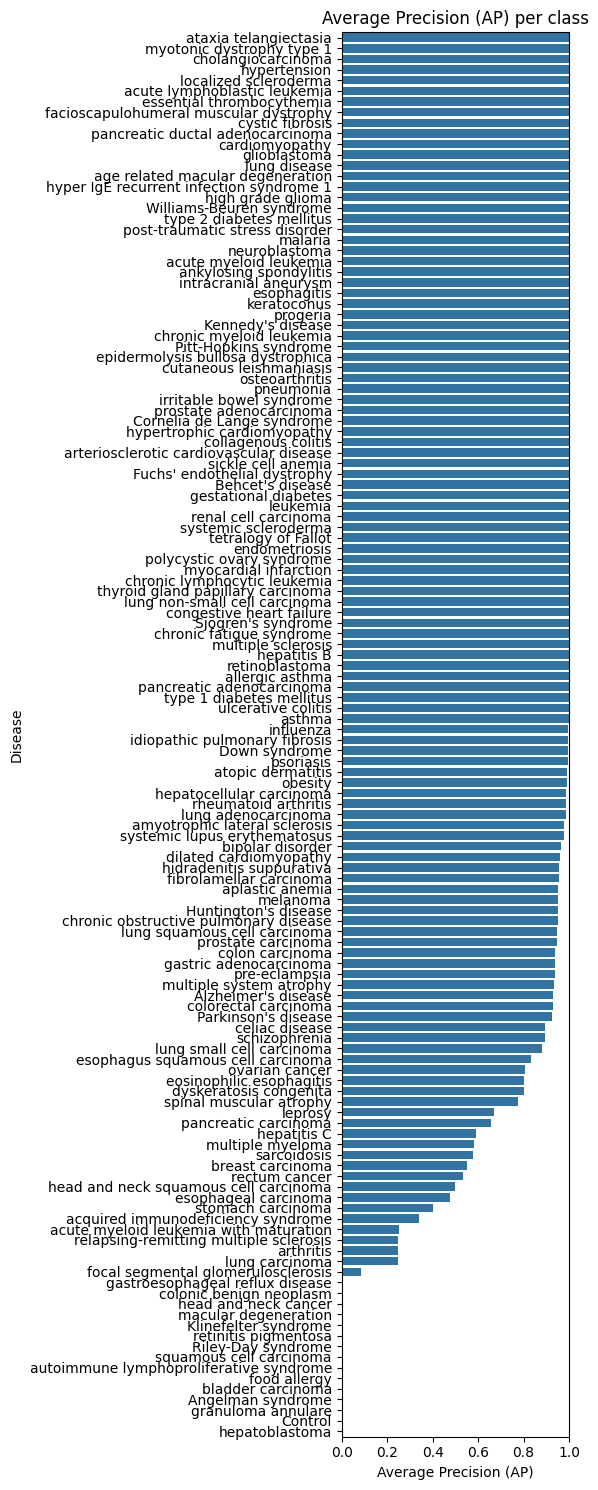

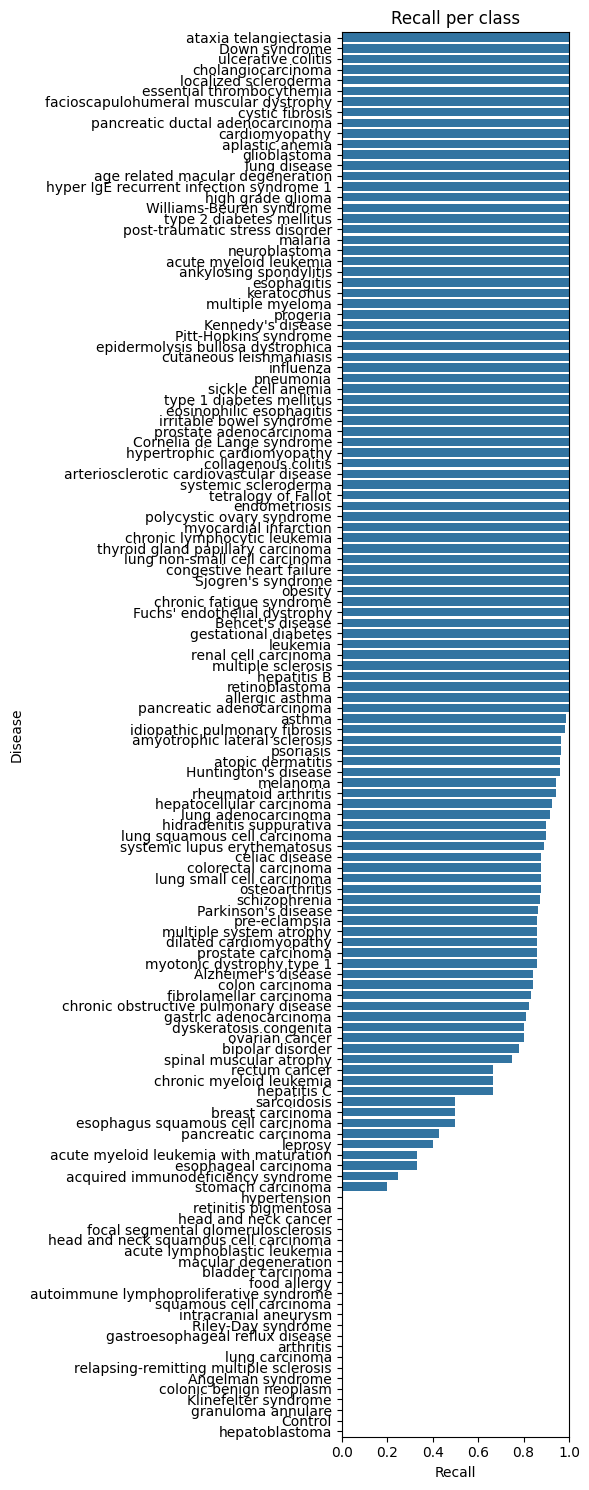

In [214]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
from sklearn.metrics import average_precision_score, recall_score

# Inputs (assumed ready):
# probs  : [N, C] numpy array of class probabilities (softmax outputs)
# y_true : [N] numpy array of int labels [0..C-1]
# classes: list of class names (length C)

C = len(classes)

# 1) Average Precision (OvR, one per class)
y_true_bin = label_binarize(y_true, classes=np.arange(C))
ap_per_class = average_precision_score(y_true_bin, probs, average=None)  # shape [C]

# 2) Recall per class (from hard predictions)
y_pred = probs.argmax(axis=1)
recall_per_class = recall_score(y_true, y_pred, labels=np.arange(C), average=None, zero_division=0)

# 3) Plot helper
def vertical_barplot(metric_vals, title):
    order = np.argsort(metric_vals)[::-1]      # sort descending
    vals_sorted = metric_vals[order]
    doids = [idx_2_dis.get(c, str(c)) for c in classes]  # map to DOIDs
    names = [doid_to_term.get(c, c) for c in doids]  # map to names
    labels_sorted = np.array(names)[order]

    plt.figure(figsize=(6, 15))   # taller fig for many classes
    sns.barplot(x=vals_sorted, y=labels_sorted, orient="h")
    plt.xlabel(title)
    plt.ylabel("Disease")
    plt.title(f"{title} per class")
    plt.xlim(0, 1)
    plt.tight_layout()
    plt.show()

# 4) Make vertical barplots
vertical_barplot(ap_per_class, "Average Precision (AP)")
vertical_barplot(recall_per_class, "Recall")


In [168]:
from sklearn.metrics import precision_recall_curve

threshold = 0.001
for i, cls in enumerate(classes):
    
    y_true_bin = (y_true == i).astype(int)
    y_score = probs[:, i]
    y_pred_bin = (y_score >= threshold).astype(int)
    
    prec = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    rec  = recall_score(y_true_bin, y_pred_bin, zero_division=0)
    
    doid = idx_2_dis[i]
    print(f"{doid} | Precision={prec:.2f}, Recall={rec:.2f}")
    

DOID:2280 | Precision=0.00, Recall=1.00
Control | Precision=0.50, Recall=0.87
DOID:12704 | Precision=0.00, Recall=0.00
DOID:14330 | Precision=0.01, Recall=0.75
DOID:2729 | Precision=0.00, Recall=0.00
DOID:1909 | Precision=0.00, Recall=0.40
DOID:3717 | Precision=0.00, Recall=1.00
DOID:3907 | Precision=0.00, Recall=0.83
DOID:3310 | Precision=0.01, Recall=0.13
DOID:3910 | Precision=0.00, Recall=0.80
DOID:2377 | Precision=0.01, Recall=0.22
DOID:2841 | Precision=0.03, Recall=0.96
DOID:8577 | Precision=0.14, Recall=1.00
DOID:5419 | Precision=0.00, Recall=0.00
DOID:1520 | Precision=0.01, Recall=1.00
DOID:9074 | Precision=0.06, Recall=0.98
DOID:11722 | Precision=0.00, Recall=0.25
DOID:0050156 | Precision=0.00, Recall=0.62
DOID:14250 | Precision=0.00, Recall=0.50
DOID:8893 | Precision=0.03, Recall=0.52
DOID:5517 | Precision=0.00, Recall=0.00
DOID:684 | Precision=0.01, Recall=0.94
DOID:5409 | Precision=0.01, Recall=0.83
DOID:1024 | Precision=0.01, Recall=0.88
DOID:11727 | Precision=0.00, Recall=

In [154]:
classes

array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,
        11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,
        22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,
        33.,  34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,
        44.,  45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,
        55.,  56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,
        66.,  67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,
        77.,  78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,
        88.,  89.,  90.,  91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,
        99., 100., 101., 102., 103., 104., 105., 106., 107., 108., 109.,
       110., 111., 112., 113., 114., 115., 116., 117., 118., 119., 120.,
       121., 122., 123., 124., 125., 126., 127., 128., 129., 130., 131.],
      dtype=float32)

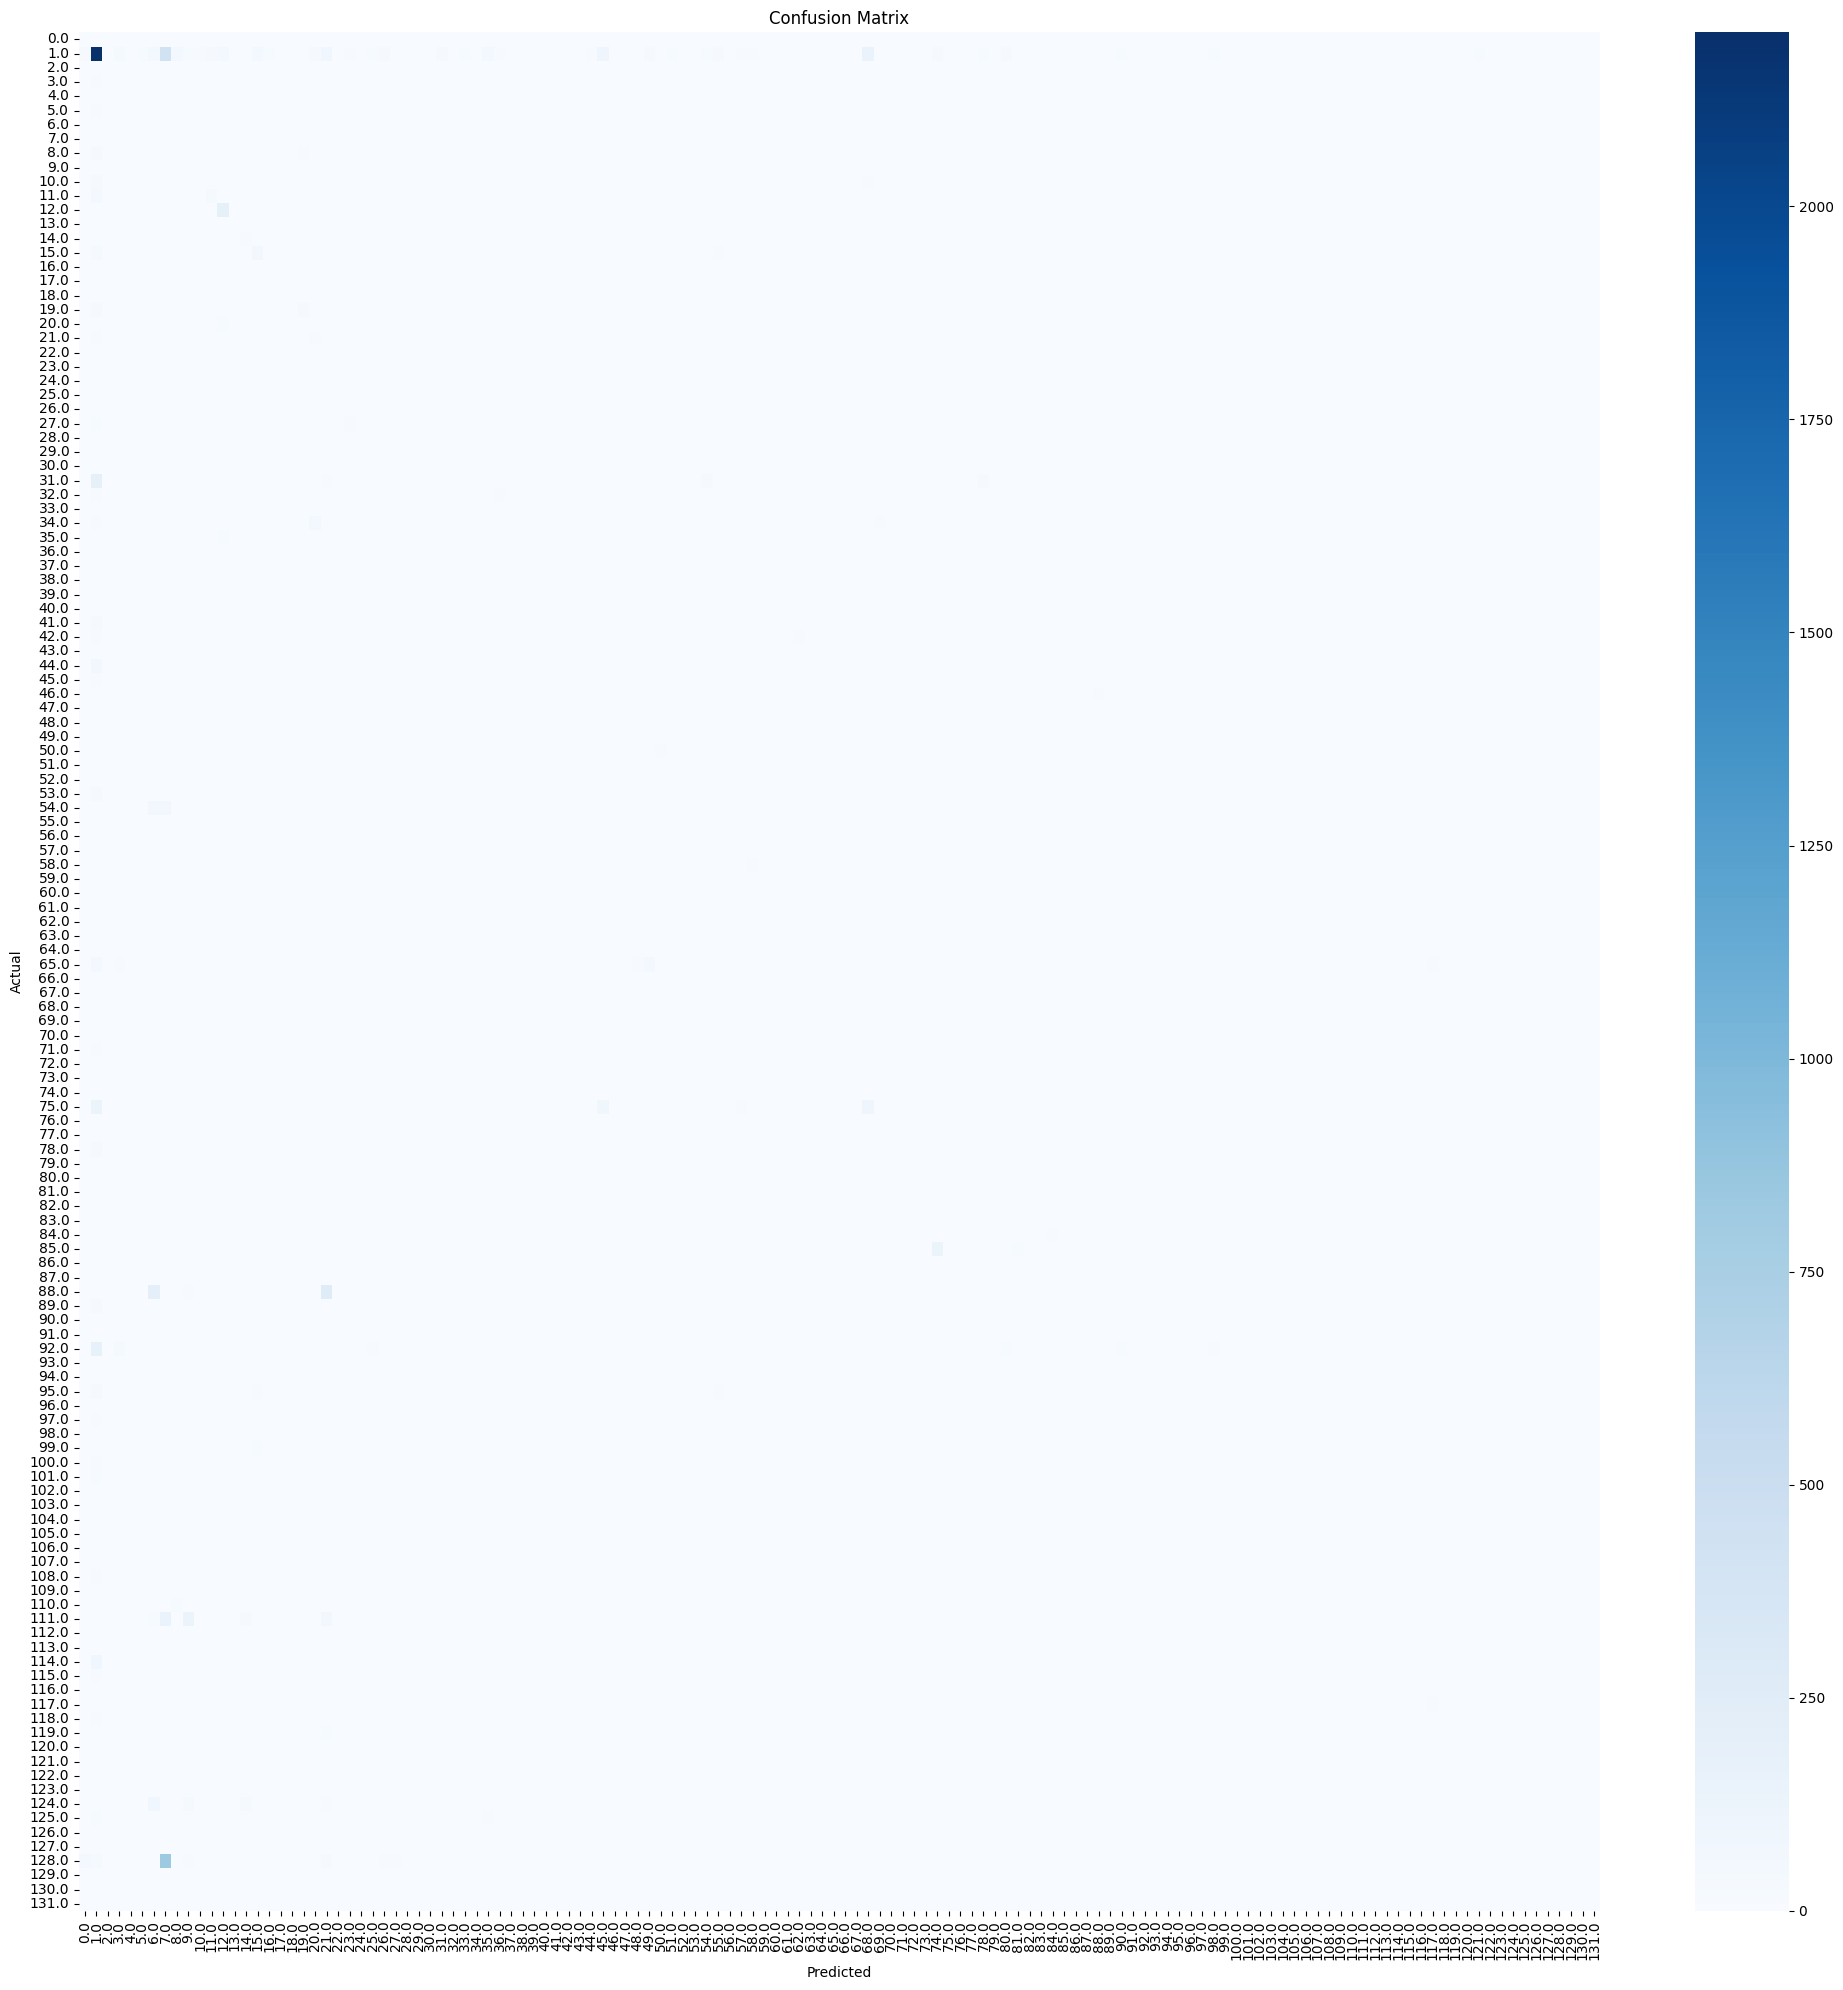

In [139]:

plt.figure(figsize=(20, 20))
sns.heatmap(cm, annot=False, fmt="", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


In [78]:
import sys
sys.path.append("../..")
from src.utils import utils as ut
df_info = ut.load_dsa_info()

counts = df_info["control_case_sample_count"].values
all_counts = [int(c.split("|")[0]) + int(c.split("|")[1]) for c in counts if "|" in c]
df_info = df_info.copy()
df_info["total_counts"] = all_counts

# filter by bulk
df_info = df_info.query(f"library_strategy in ['RNA-Seq' , 'Microarray']")
s_0 = df_info["total_counts"].sum()
d_0 = df_info["diseaseid"].nunique()
dt_0 = df_info["accession"].nunique()

# filter by species
df_info = df_info.query(f"organism == 'Homo sapiens'")
s_1 = df_info["total_counts"].sum()
d_1 = df_info["diseaseid"].nunique()
dt_1 = df_info["accession"].nunique()

# filter by mapping
_do_g = ut.load_do_graph()
_uml_2_doid = ut.get_umls_2_doid_mapping(_do_g)
df_info = df_info.query(f"diseaseid in {list(_uml_2_doid.keys())}")
s_2 = df_info["total_counts"].sum()
d_2 = df_info["diseaseid"].nunique()
dt_2 = df_info["accession"].nunique()

# filter by library stratergy
# df_info = df_info.query(f"library_strategy in ['RNA-Seq']")
# s_3 = df_info["total_counts"].sum()
# d_3 = df_info["diseaseid"].nunique()
# dt_3 = df_info["accession"].nunique()


In [79]:
df_info["control"] = [int(x.split("|")[0]) for x in df_info["control_case_sample_count"]]
df_info["case"] = [int(x.split("|")[1]) for x in df_info["control_case_sample_count"]]

In [82]:
diseases = list()
for d in df_info["diseaseid"].unique():
    if df_info[df_info["diseaseid"] == d]["accession"].nunique() >= 5:
        diseases.append(d)

print(len(diseases))

128


In [85]:
df_info.query(f"diseaseid in {diseases}")["control"].sum()

46154

In [92]:
df_info[df_info["diseaseid"]=="C0035235"]

,dsaid,accession,platform,deg_count,disease,diseaseid,tissue,data_source,library_strategy,organism,control_case_sample_count,definition,total_counts,control,case
2207,DSA02208,GSE77087,GPL10558,1000,Respiratory Syncytial Virus Infectious Disease,C0035235,Blood,GEO,Microarray,Homo sapiens,23|61,DO:A viral infectious disease that results_in ...,84,23,61
2208,DSA02209,GSE77087,GPL10558,1000,Respiratory Syncytial Virus Infectious Disease,C0035235,Blood,GEO,Microarray,Homo sapiens,23|20,DO:A viral infectious disease that results_in ...,43,23,20


In [87]:
diseases

['C0027126',
 'C0699791',
 'C0002736',
 'C0699790',
 'C0152013',
 'C0684249',
 'C0600139',
 'C0878544',
 'C0009402',
 'C0011854',
 'C0011860',
 'C0023467',
 'C0001418',
 'C0157946',
 'C0004096',
 'C0004153',
 'C0678222',
 'C0032460',
 'C0033860',
 'C0007134',
 'C0007193',
 'C1335177',
 'C0002395',
 'C0030567',
 'C1140680',
 'C0024141',
 'C0011615',
 'C0206624',
 'C0334287',
 'C0011633',
 'C0238190',
 'C0032914',
 'C0018671',
 'C0023473',
 'C0025202',
 'C0263666',
 'C0024117',
 'C0026691',
 'C0021400',
 'C0026769',
 'C0003873',
 'C0036220',
 'C0009375',
 'C0014175',
 'C1800706',
 'C0035455',
 'C0016781',
 'C0009324',
 'C0010674',
 'C0002895',
 'C0007570',
 'C1168401',
 'C1335302',
 'C0020179',
 'C0085207',
 'C0022602',
 'C0017636',
 'C0279626',
 'C0007766',
 'C1879321',
 'C0206698',
 'C0041327',
 'C0007137',
 'C0026847',
 'C0033300',
 'C0028754',
 'C0017638',
 'C0032463',
 'C0040028',
 'C0019196',
 'C0027819',
 'C0026764',
 'C0341106',
 'C0023434',
 'C0017668',
 'C0036341',
 'C0017661',